In [1]:
!pip install fredapi

            UK Real GDP  UK CPI Inflation %  Uk Unemployment Rate
1855-01-01          NaN                 NaN                  3.42
1855-02-01          NaN                 NaN                  4.04
1855-03-01          NaN                 NaN                  4.20
1855-04-01          NaN                 NaN                  4.14
1855-05-01          NaN                 NaN                  3.64
1855-06-01          NaN                 NaN                  4.07
1855-07-01          NaN                 NaN                  4.02
1855-08-01          NaN                 NaN                  3.90
1855-09-01          NaN                 NaN                  3.42
1855-10-01          NaN                 NaN                  3.27


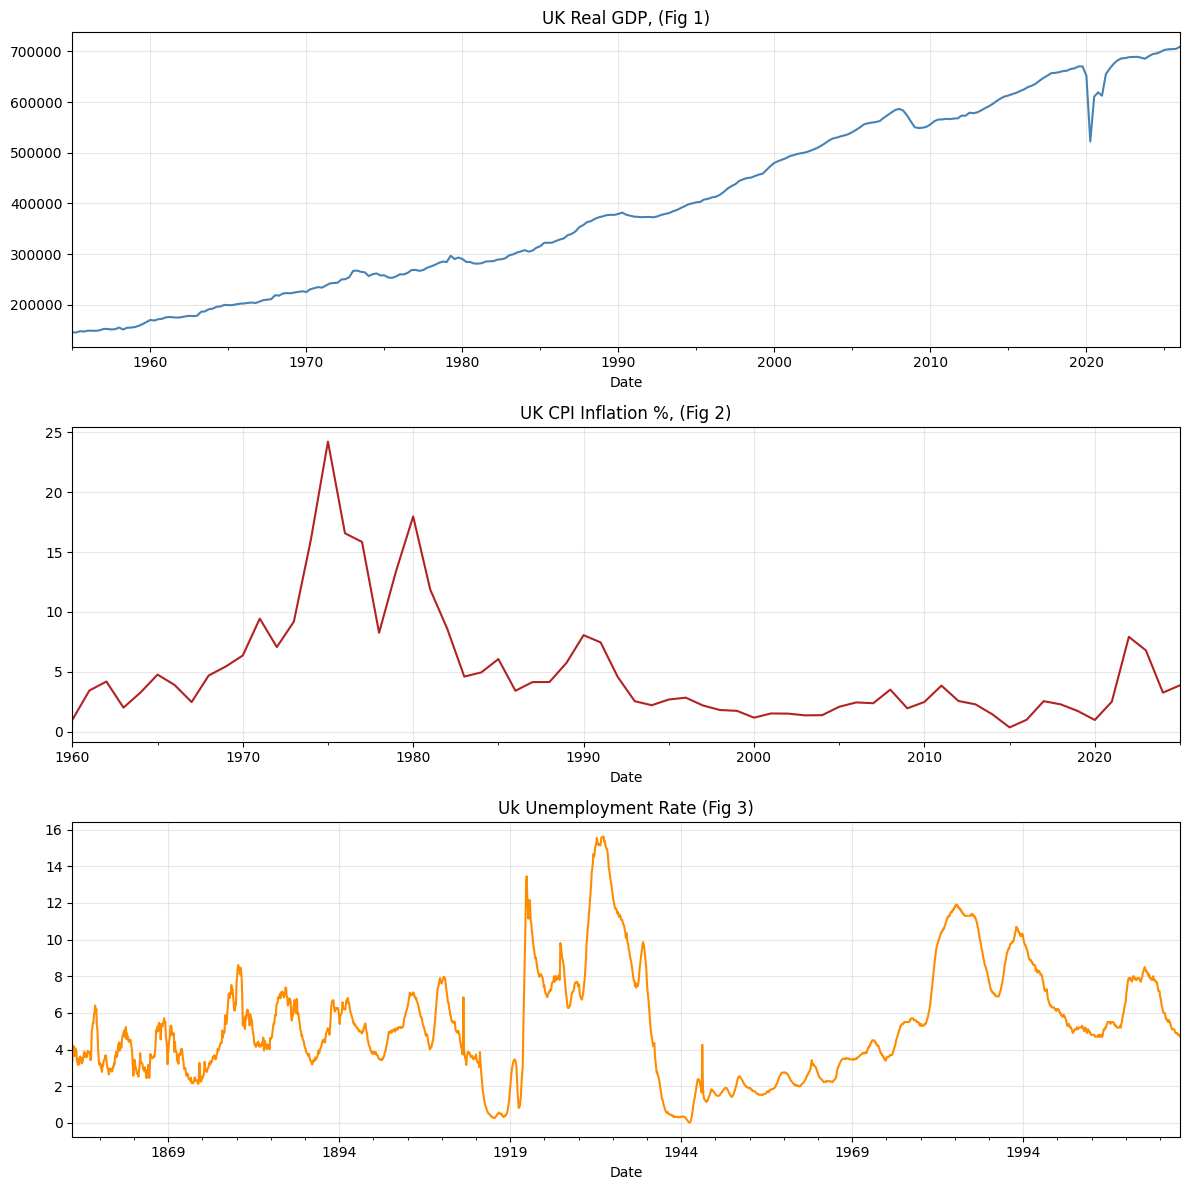

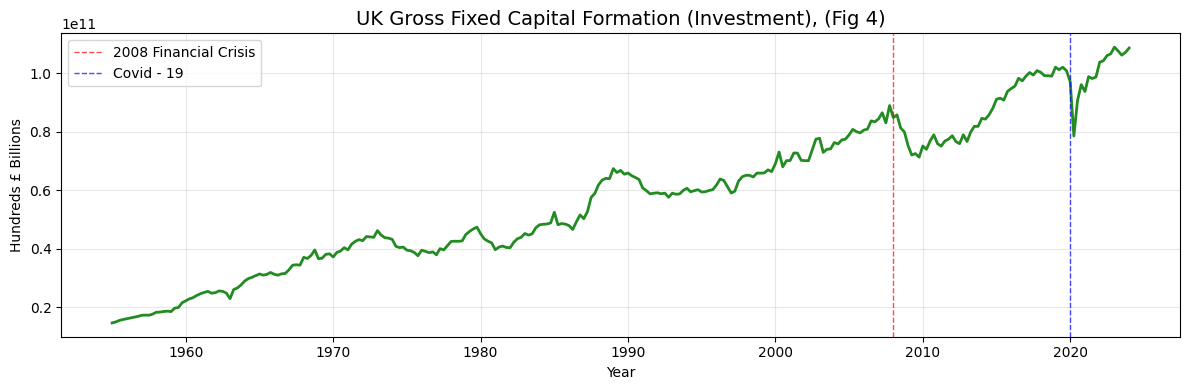

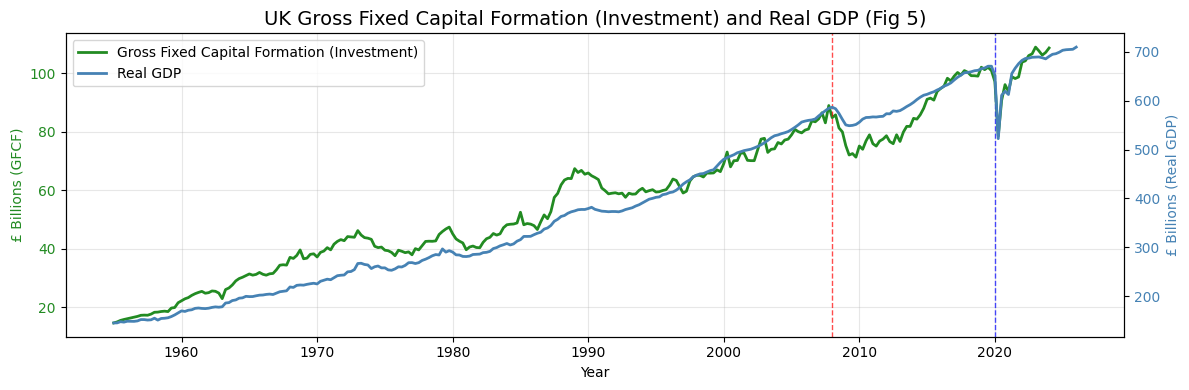

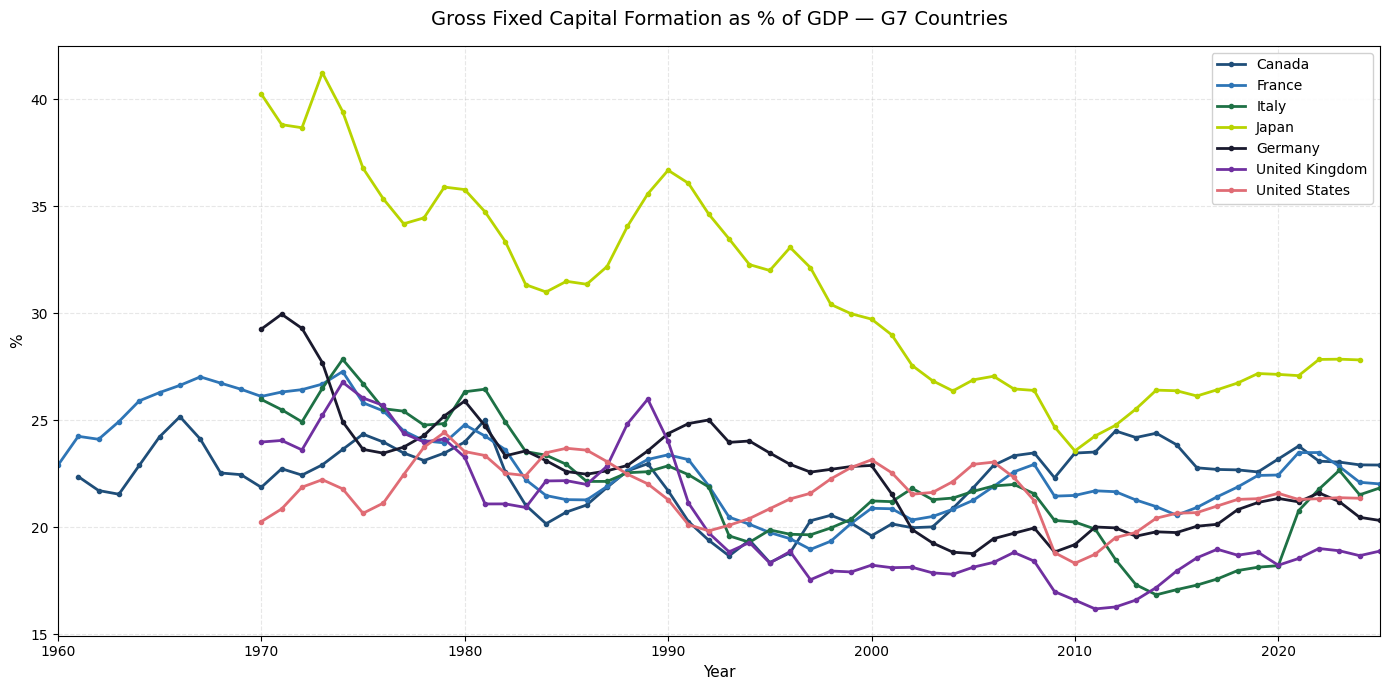

In [21]:
from matplotlib import lines
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt

#fredapi key

fred = Fred(api_key='88ad56fee8502dd5d3634bc8cc2473a8')

#dictionary of FRED codes and readable names
series = {
    'NGDPRSAXDCGBQ': 'UK Real GDP',
    'FPCPITOTLZGGBR': 'UK CPI Inflation %',
    'AURUKM': 'Uk Unemployment Rate',
}

data = {}
for code, name in series.items():
    data[name] = fred.get_series(code)

df_confined = pd.DataFrame(data)
print(df_confined.head(10))

fig, axes = plt.subplots(3, 1, figsize=(12,12))

df_confined['UK Real GDP'].dropna().plot(ax=axes[0], title='UK Real GDP, (Fig 1)', color='steelblue')
df_confined['UK CPI Inflation %'].dropna().plot(ax=axes[1], title='UK CPI Inflation %, (Fig 2)', color='firebrick')
df_confined['Uk Unemployment Rate'].dropna().plot(ax=axes[2], title='Uk Unemployment Rate (Fig 3)', color='darkorange')

for ax in axes:
  ax.grid(True, alpha=0.3)
  ax.set_xlabel('Date')


plt.tight_layout()
plt.savefig('uk_macro_dashboard.png', dpi=150)
plt.show()

#fig4

uk_gfcf = fred.get_series('GBRGFCFQDSNAQ')
plt.figure(figsize=(12,4)) # Modified figsize to make it smaller
plt.plot(uk_gfcf.index, uk_gfcf.values, color='forestgreen', linewidth=2)
plt.title('UK Gross Fixed Capital Formation (Investment), (Fig 4)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Hundreds £ Billions')
plt.grid(True, alpha=0.3)
plt.axvline(x=pd.Timestamp('2008-01-01'), color = 'red', linestyle='--', linewidth=1, alpha=0.7, label = '2008 Financial Crisis' )
plt.axvline(x=pd.Timestamp('2020-01-01'), color = 'blue', linestyle='--', linewidth=1, alpha=0.7, label = 'Covid - 19')
plt.legend()
plt.tight_layout()
plt.savefig('uk_gfcf.png', dpi=150)
plt.show()


#fig5 - Using a secondary y-axis for Real GDP
fig, ax1 = plt.subplots(figsize=(12,4))

uk_gfcf = fred.get_series('GBRGFCFQDSNAQ')
uk_gdpc = fred.get_series('NGDPRSAXDCGBQ')

#Gross Fixed Capital primary y-axis
ax1.plot(uk_gfcf.index, uk_gfcf.values / 1e9, color='forestgreen', linewidth=2, label='Gross Fixed Capital Formation (Investment)')
ax1.set_xlabel('Year')
ax1.set_ylabel('£ Billions (GFCF)', color='forestgreen')
ax1.tick_params(axis='y', labelcolor='forestgreen')

#secondary y-axis for Real GDP
ax2 = ax1.twinx()
ax2.plot(uk_gdpc.index, uk_gdpc.values / 1e3, color='steelblue', linewidth=2, label='Real GDP')
ax2.set_ylabel('£ Billions (Real GDP)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

#title and grid
plt.title('UK Gross Fixed Capital Formation (Investment) and Real GDP (Fig 5)', fontsize=14)
ax1.grid(True, alpha=0.3)

#legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

ax1.axvline(x=pd.Timestamp('2008-01-01'), color='red', linestyle='--', linewidth=1, alpha=0.7, label='2008 Financial Crisis')
ax1.axvline(x=pd.Timestamp('2020-01-01'), color='blue', linestyle='--', linewidth=1, alpha=0.7, label='Covid - 19')

plt.tight_layout()
plt.savefig('uk_gfcf_gdp.png', dpi=150)
plt.show()

#g7 code for gross domestic
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/G7_GFCF3.xlsx", header=None)

df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Convert year column names to integers. Ensure they are strings first to handle '1960.0' format.
df.columns = [int(float(col)) if isinstance(col, (float, str)) and str(col).replace('.', '', 1).isdigit() else col for col in df.columns]

df = df.set_index('CountryName').T
df.index = df.index.astype(int)

# Colours
colours = {
    'Canada':        '#1f4e79',
    'France':        '#2e75b6',
    'Germany':       '#1a1a2e',
    'Italy':         '#1e7145',
    'Japan':         '#b8d400',
    'United Kingdom':'#7030a0',
    'United States': '#e06c75'
}

plt.figure(figsize=(14, 7))

for country in df.columns:
    colour = colours.get(country, None)
    plt.plot(
        df.index,
        df[country],
        label=country,
        linewidth=2,
        color=colour,
        marker='o',
        markersize=3
    )

plt.title('Gross Fixed Capital Formation as % of GDP — G7 Countries', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=11)
plt.ylabel('%', fontsize=11)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(df.index.min(), df.index.max())
plt.tight_layout()
plt.savefig('gfcf_g7.png', dpi=150)
plt.show()




Uk Investment Conclusions

This code compares key UK macroeconomic data relevant to infastrcure investment, including Real GDP, inflation, unemploymnet and Gross Fixed Income Capital using the Fred API.

This data shows: firstly, that UK fixed income gross capital formation is strongly correlated with UK real GDP. However, the UK experinced an 18% decline in the advent of the 2008 recession, the largest of any G7 state.

Furthermore, the actual GFCF share of GDP has declined actually declined and has remained below pre 2008 levels, see final image, and is below all G7 states.

The implications of this are that there does exist a large negative investment cap which has the possibility to be filled to stimulate economic growth. However, persitantly high interest rates due to inflationary fears has meant that the cost for financing infastructure projects over the long term has meant this gap is unable to be filled. Coupled, with lackluster policy in regards to infastructure and planning this means the gap is unlikely to be filled any time soon despite the immense potential that could be realised if this gap is filled.